<a href="https://www.kaggle.com/code/sonawanelalitsunil/cardiac-arrest-dataset-ml-98-54?scriptVersionId=250430801" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cardiac-arrest-dataset/cardiac arrest dataset.csv


## Title :
Cardiac Arrest Dataset

## Description:
This dataset provides detailed information on cardiac arrest incidents, including patient demographics, event characteristics, response times, medical interventions, and outcomes. It can be used to analyze patterns in cardiac arrests, identify key factors influencing survival rates, evaluate the effectiveness of emergency responses, and support predictive modeling for early intervention. Researchers and healthcare professionals can use this dataset to improve public health strategies and clinical protocols related to cardiac emergencies.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/cardiac-arrest-dataset/cardiac arrest dataset.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.duplicated().sum()

723

In [9]:
df.shape

(1025, 14)

In [10]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [11]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## Data visualizations

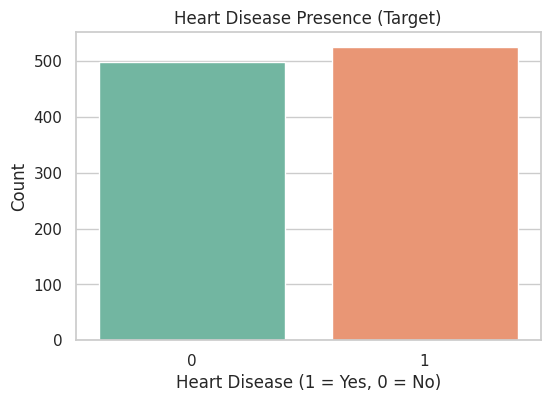

In [12]:
# Set plot style
sns.set(style="whitegrid", palette="Set2")

# Countplot for target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title("Heart Disease Presence (Target)")
plt.xlabel("Heart Disease (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

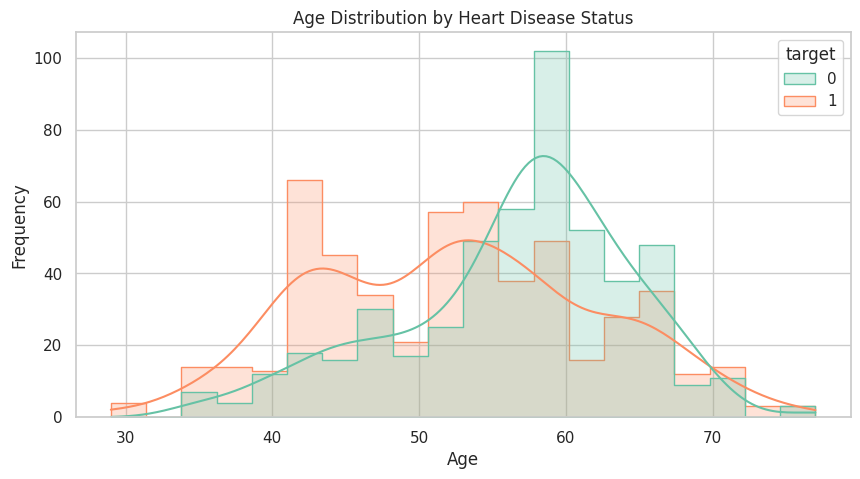

In [13]:
# Age distribution by target
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True, element='step')
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

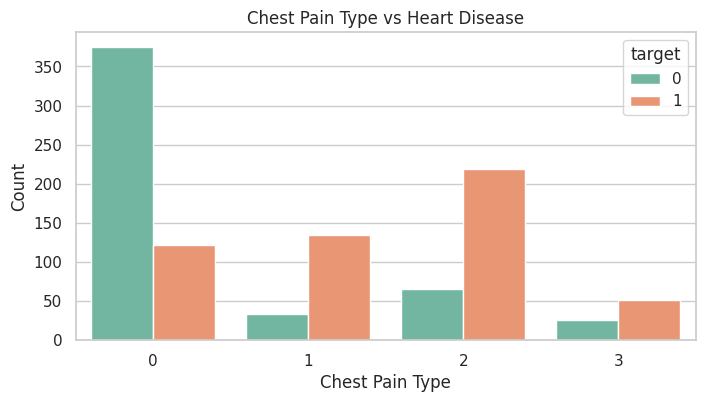

In [14]:
# Chest pain type vs target
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='cp', hue='target')
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

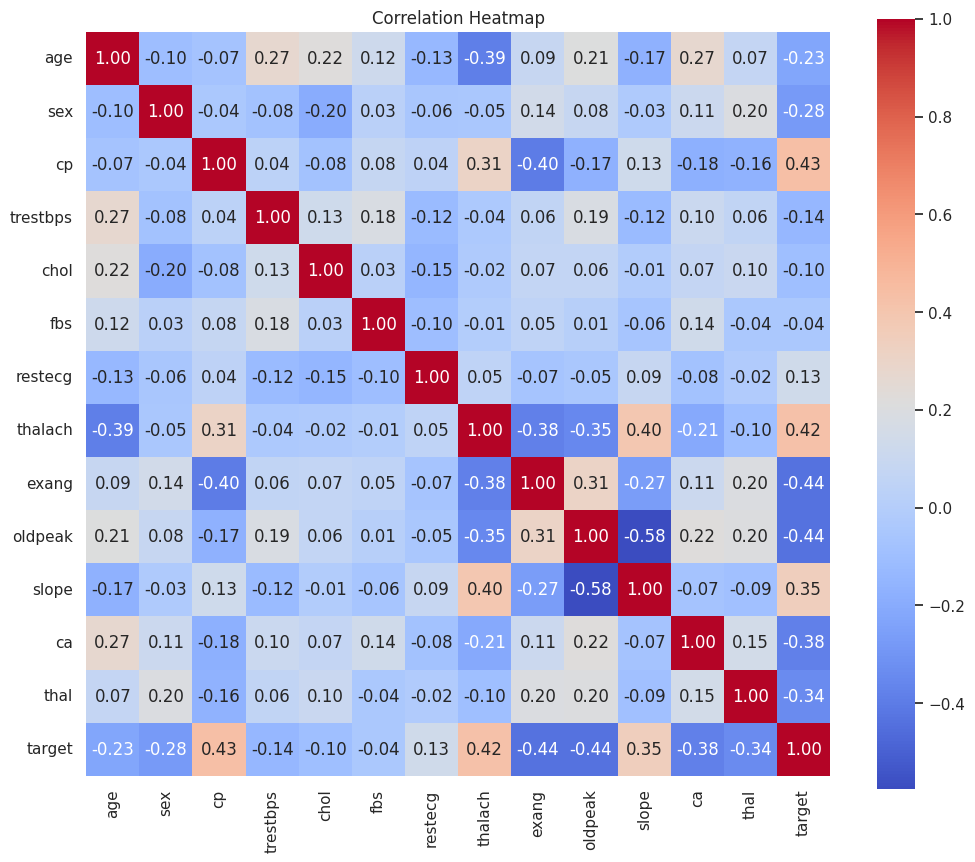

In [15]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Correlation Heatmap")
plt.show()


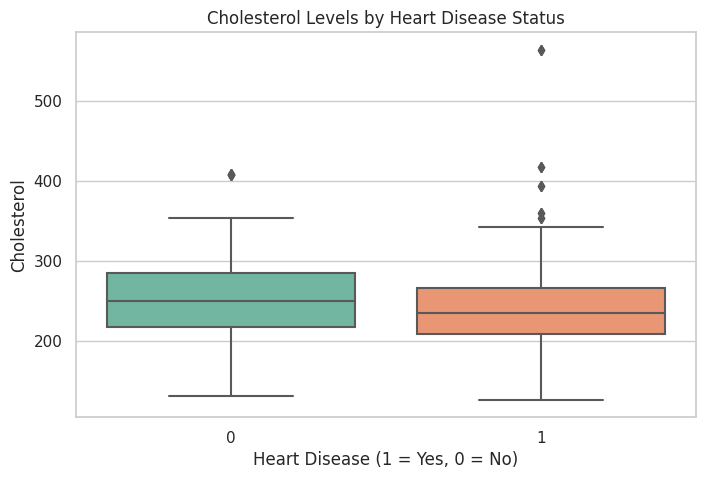

In [16]:
# Boxplot of cholesterol by target
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='target', y='chol')
plt.title("Cholesterol Levels by Heart Disease Status")
plt.xlabel("Heart Disease (1 = Yes, 0 = No)")
plt.ylabel("Cholesterol")
plt.show()

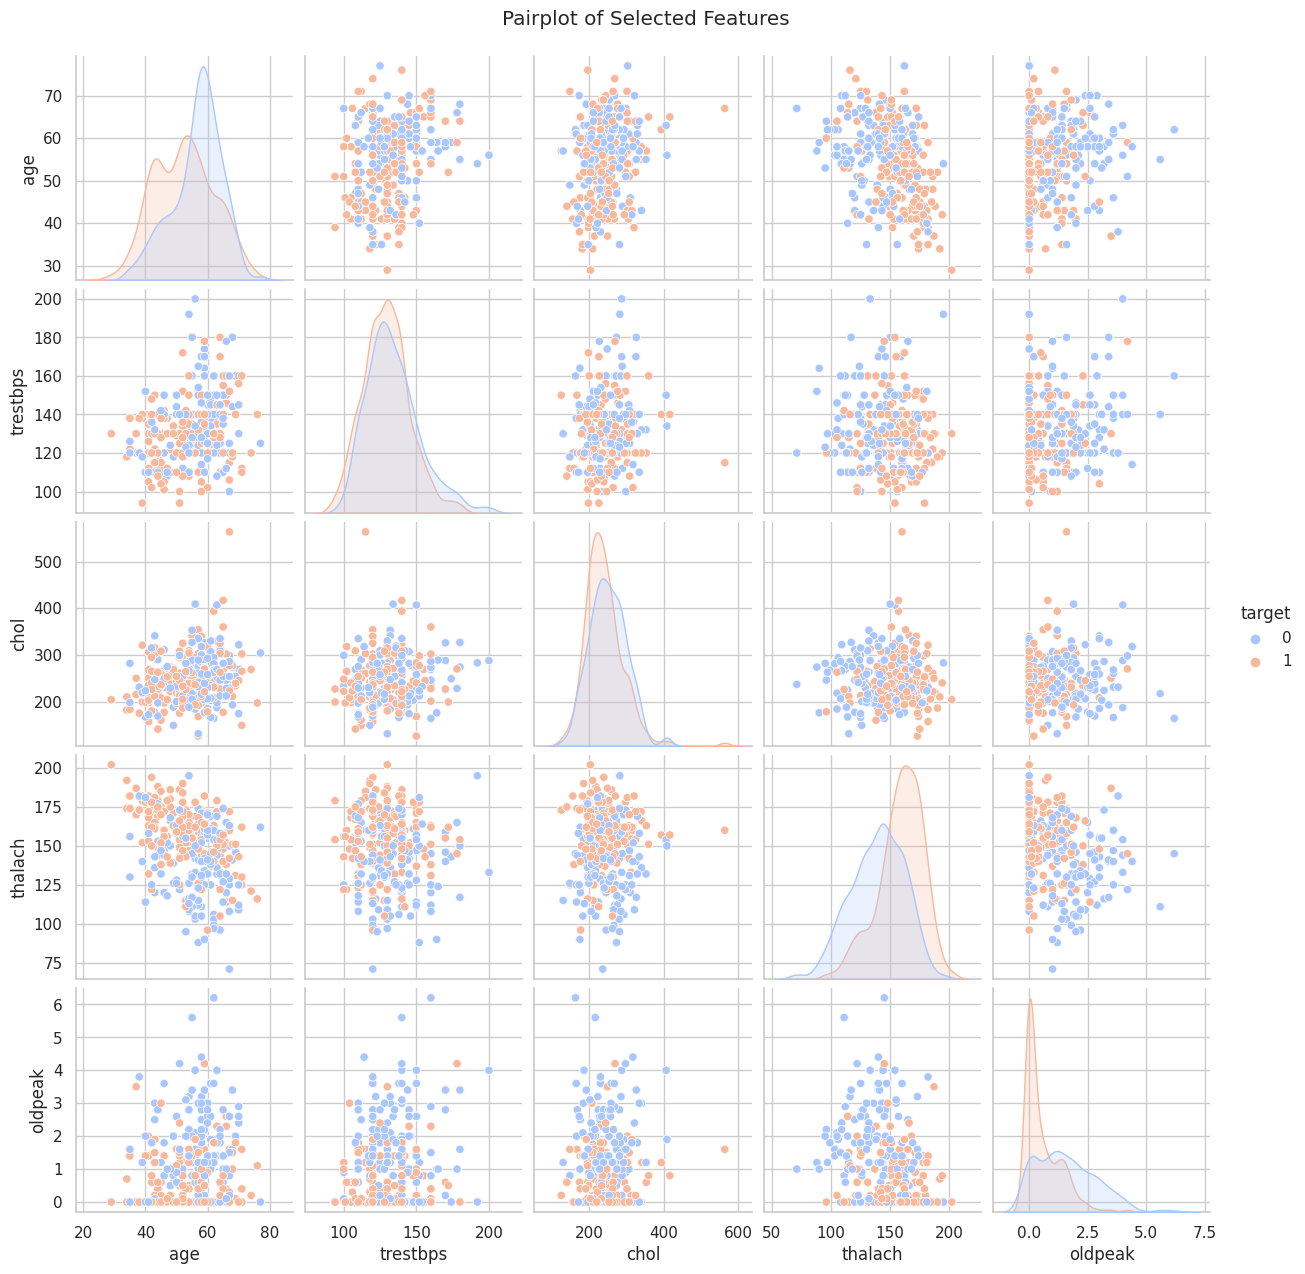

In [17]:
# Pairplot for selected features
selected = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(df[selected], hue='target', diag_kind='kde', palette='coolwarm')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

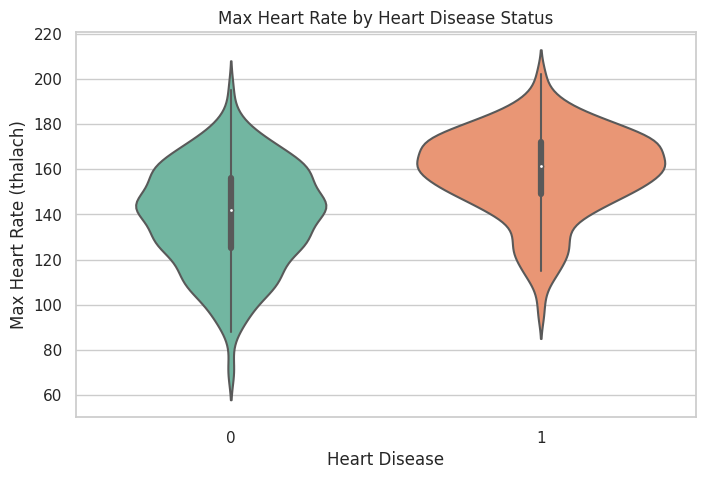

In [18]:
# Violin plot of thalach (max heart rate) by target
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='target', y='thalach', inner='box')
plt.title("Max Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Max Heart Rate (thalach)")
plt.show()

## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [20]:
# Handle missing values (optional)
df = df.dropna()

# Label encode categorical columns
label_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
# Models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = round(acc * 100, 2)

# Display results
print("Model Accuracy (in %):")
for model, acc in results.items():
    print(f"{model}: {acc}%")


Model Accuracy (in %):
Logistic Regression: 79.51%
Decision Tree: 98.54%
Random Forest: 98.54%
Gradient Boosting: 93.17%
Support Vector Machine: 68.29%
K-Nearest Neighbors: 73.17%


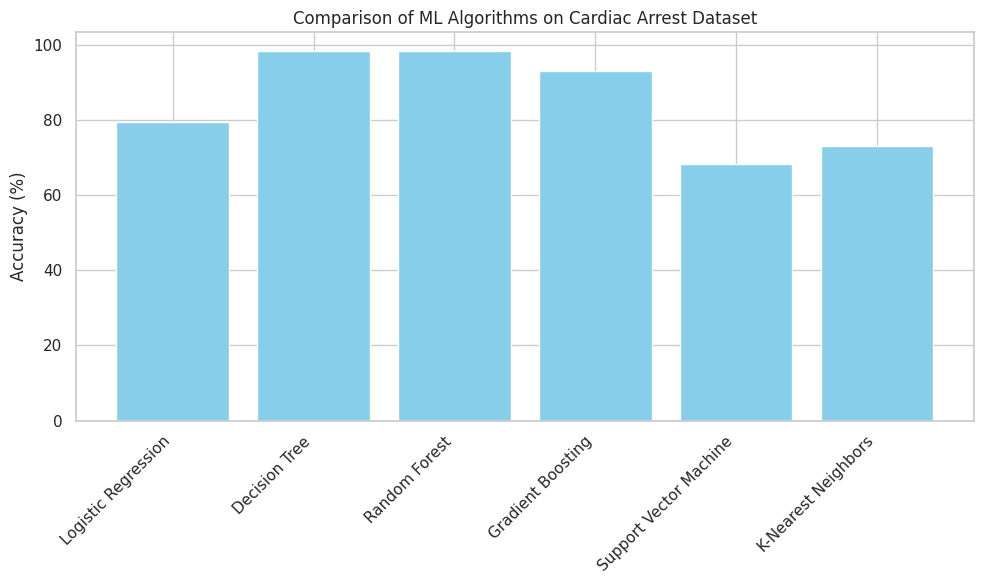

In [22]:
# Bar chart of accuracies
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of ML Algorithms on Cardiac Arrest Dataset')
plt.tight_layout()
plt.show()

## Thank you pls upvote!!!!